# Hadoop

- Data sets that are so large or complex that traditional data processing application software is inadequate to deal with them.
- Data analysis requires massively parallel software running on several servers.
- **Volume, Variety, Velocity, Variability and Veracity** describe Big Data properties.

![https://github.com/veekaybee/data-lake-talk/](https://github.com/pnavaro/big-data/blob/master/notebooks/images/bigdata.png?raw=1)

![Hadoop Logo](https://github.com/pnavaro/big-data/blob/master/notebooks/images/hadoop.png?raw=1)
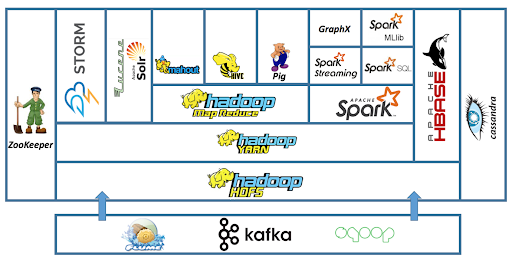
- Framework for running applications on large cluster.
- The Hadoop framework transparently provides applications both reliability and data motion.
- Hadoop implements the computational paradigm named **Map/Reduce**, where the application is divided into many small fragments of work, each of which may be executed or re-executed on any node in the cluster.
- It provides a distributed file system (HDFS) that stores data on the compute nodes, providing very high aggregate bandwidth across the cluster.
- Both MapReduce and the **Hadoop Distributed File System** are designed so that node failures are automatically handled by the framework.


## HDFS

* It is a distributed file systems.
* HDFS is highly fault-tolerant and is designed to be deployed on low-cost hardware.
* HDFS is suitable for applications that have large data sets.
* HDFS provides interfaces to move applications closer to where the data is located. The computation is much more efficient when the size of the data set is huge.
* HDFS consists of a single NameNode with a number of DataNodes which manage storage.
* HDFS exposes a file system namespace and allows user data to be stored in files.
    1. A file is split by the NameNode into blocks stored in DataNodes.
    2. The [NameNode](http://svmass2.mass.uhb.fr:50070) executes operations like opening, closing, and renaming files and directories.
    3. The [Secondary NameNode](http://svmass2.mass.uhb.fr:50090/status.html) stores information from **NameNode**.
    4. The **DataNodes** manage perform block creation, deletion, and replication upon instruction from the NameNode.
    5. The placement of replicas is optimized for data reliability, availability, and network bandwidth utilization.
    6. User data never flows through the NameNode.
* Files in HDFS are write-once and have strictly one writer at any time.
* The DataNode has no knowledge about HDFS files.

## Accessibility

All [HDFS commands](http://hadoop.apache.org/docs/stable/hadoop-project-dist/hadoop-common/FileSystemShell.html)  are invoked by the bin/hdfs Java script:
```shell
hdfs [SHELL_OPTIONS] COMMAND [GENERIC_OPTIONS] [COMMAND_OPTIONS]
```
## Manage files and directories
```shell
hdfs dfs -ls -h -R # Recursively list subdirectories with human-readable file sizes.
hdfs dfs -cp  # Copy files from source to destination
hdfs dfs -mv  # Move files from source to destination
hdfs dfs -mkdir /foodir # Create a directory named /foodir
hdfs dfs -rmr /foodir   # Remove a directory named /foodir
hdfs dfs -cat /foodir/myfile.txt #View the contents of a file named /foodir/myfile.txt
```

## Transfer between nodes

### put
```shell
hdfs fs -put [-f] [-p] [-l] [-d] [ - | <localsrc1> .. ]. <dst>
```
Copy single src, or multiple srcs from local file system to the destination file system.

Options:

    -p : Preserves rights and modification times.
    -f : Overwrites the destination if it already exists.

```shell
hdfs fs -put localfile /user/hadoop/hadoopfile
hdfs fs -put -f localfile1 localfile2 /user/hadoop/hadoopdir
```
Similar to the fs -put command
- `moveFromLocal` : to delete the source localsrc after copy.
- `copyFromLocal` : source is restricted to a local file
- `copyToLocal` : destination is restricted to a local file

![hdfs blocks](https://github.com/pnavaro/big-data/blob/master/notebooks/images/hdfs-fonctionnement.jpg?raw=1)

The Name Node is not in the data path. The Name Node only provides the map of where data is and where data should go in the cluster (file system metadata).

## YARN

*YARN takes care of resource management and job scheduling/monitoring.*

- The **ResourceManager** is the ultimate authority that arbitrates resources among all the applications in the system. It has two components: **Scheduler** and **ApplicationsManager**.
- The **NodeManager** is the per-machine framework agent who is responsible for **Containers**, monitoring their resource usage (cpu, memory, disk, network) and reporting the same to the **ResourceManager/Scheduler**.

The per-application **ApplicationMaster** negotiates resources from the ResourceManager and working with the NodeManager(s) to execute and monitor the tasks.

- The **Scheduler** is responsible for allocating resources to the applications.

- The **ApplicationsManager** is responsible for accepting job-submissions, tracking their status and monitoring for progress.

![Yarn in Hadoop documentation](https://github.com/pnavaro/big-data/blob/master/notebooks/images/yarn_architecture.png?raw=1)
Source: http://hadoop.apache.org/docs/stable/hadoop-yarn/hadoop-yarn-site/yarn_architecture.gif

## Hadoop on Colab

Hadoop mainly works on 3 different modes:

*   Standalone Mode
*   Pseudo-distributed Mode
*   Fully-distributed Mode


**Standalone Mode**

By default, Hadoop is configured to run in a non distributed mode. It runs as a single Java process. Instead of HDFS, this mode utilizes the local file system. This mode is useful for debugging and there isn't any need to configure core-site.xml, hdfs-site.xml, mapred-site.xml, masters & slaves. Stand-alone mode is usually the fastest mode in Hadoop.

**Pseudo-distributed Mode**

Hadoop can also run on a single node in a Pseudo-distributed mode. In this mode, each daemon runs on separate java processes. In this mode custom configuration is required (core-site.xml, hdfs-site.xml, mapred-site.xml). Here HDFS is utilized for input and output. This mode of deployment is useful for testing and debugging purposes.

**Fully-distributed Mode**

This is the production mode of Hadoop. In this mode typically one machine in the cluster is designated as NameNode and another as Resource Manager exclusively. These are masters. All other nodes act as Data Node and Node Manager. These are the slaves. Configuration parameters and environment need to be specified for Hadoop Daemons.

Hadoop is a java programming-based data processing framework

OpenJDK is a development environment for building applications, applets, and components using the Java programming language.

In [ ]:
#Checking the installed Java version
!java -version

openjdk version "11.0.15" 2022-04-19
OpenJDK Runtime Environment (build 11.0.15+10-Ubuntu-0ubuntu0.18.04.1)
OpenJDK 64-Bit Server VM (build 11.0.15+10-Ubuntu-0ubuntu0.18.04.1, mixed mode, sharing)


Installing java 8 for better compatibility with Hadoop

In [ ]:
#Installing java 8
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
# -q, quiet level 2: no output except for errors
#> /dev/null on the end of any command where you want to redirect all the stdout into nothingness

Switching java default version

In [ ]:
#Switching java version to use as default (choose option 2)
!update-alternatives --config java

There are 2 choices for the alternative java (providing /usr/bin/java).

  Selection    Path                                            Priority   Status
------------------------------------------------------------
* 0            /usr/lib/jvm/java-11-openjdk-amd64/bin/java      1111      auto mode
  1            /usr/lib/jvm/java-11-openjdk-amd64/bin/java      1111      manual mode
  2            /usr/lib/jvm/java-8-openjdk-amd64/jre/bin/java   1081      manual mode

Press <enter> to keep the current choice[*], or type selection number: 2
update-alternatives: using /usr/lib/jvm/java-8-openjdk-amd64/jre/bin/java to provide /usr/bin/java (java) in manual mode


In [ ]:
#Switching javac version to use as default (choose option 2)
!update-alternatives --config javac

There are 2 choices for the alternative javac (providing /usr/bin/javac).

  Selection    Path                                          Priority   Status
------------------------------------------------------------
* 0            /usr/lib/jvm/java-11-openjdk-amd64/bin/javac   1111      auto mode
  1            /usr/lib/jvm/java-11-openjdk-amd64/bin/javac   1111      manual mode
  2            /usr/lib/jvm/java-8-openjdk-amd64/bin/javac    1081      manual mode

Press <enter> to keep the current choice[*], or type selection number: 2
update-alternatives: using /usr/lib/jvm/java-8-openjdk-amd64/bin/javac to provide /usr/bin/javac (javac) in manual mode


In [ ]:
#Switching jps version to use as default (choose option 2)
!update-alternatives --config jps

There are 2 choices for the alternative jps (providing /usr/bin/jps).

  Selection    Path                                        Priority   Status
------------------------------------------------------------
* 0            /usr/lib/jvm/java-11-openjdk-amd64/bin/jps   1111      auto mode
  1            /usr/lib/jvm/java-11-openjdk-amd64/bin/jps   1111      manual mode
  2            /usr/lib/jvm/java-8-openjdk-amd64/bin/jps    1081      manual mode

Press <enter> to keep the current choice[*], or type selection number: 2
update-alternatives: using /usr/lib/jvm/java-8-openjdk-amd64/bin/jps to provide /usr/bin/jps (jps) in manual mode


In [ ]:
#Checking Java default version
!java -version

openjdk version "1.8.0_312"
OpenJDK Runtime Environment (build 1.8.0_312-8u312-b07-0ubuntu1~18.04-b07)
OpenJDK 64-Bit Server VM (build 25.312-b07, mixed mode)


Creating Java related environment variables

The JAVA_HOME is an operating system environment variable points to the file system location where the JDK or JRE was installed.

In [ ]:
#Finding the default Java path
!readlink -f /usr/bin/java | sed "s:bin/java::"

/usr/lib/jvm/java-8-openjdk-amd64/jre/


In [ ]:
#Importing os module
import os
#Creating environment variables
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["JRE_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64/jre"
os.environ["PATH"] += ":$JAVA_HOME/bin:$JRE_HOME/bin:$HADOOP_HOME/bin:$HADOOP_HOME/sbin"

## Installing Secure Shell Server (SSHD)

We need to define a means for the master node to remotely access every node in our cluster.

Hadoop uses passphrases SSH for the communication between the nodes.

SSH is a cryptographic network protocol for operating network services securely over an unsecured network.

SSH utilizes standard public key criptography to create a pair of keys for user verification: one public and one private.

In [ ]:
#It is good practice to purge before installation
!apt-get purge openssh-server -qq

In [ ]:
#Installing openssh-server
!apt-get install openssh-server -qq > /dev/null

In [ ]:
#Starting the server
!service ssh start

 * Starting OpenBSD Secure Shell server sshd
   ...done.


The port number for SSH is 22 by default

In [ ]:
!grep Port /etc/ssh/sshd_config

#Port 22
#GatewayPorts no


The pseudo distributed mode is special case of fully the distributed mode, in which the single host is localhost (our machine). We need to make sure that to access to localhost and login we do not need to enter a password. Therefore, SSH needs to be set up to allow passwordless login for the Hadoop user. The simplest way to achive this is to generate a public-private key pair.

In [ ]:
#Creating a new rsa key pair with empty password
!ssh-keygen -t rsa -P "" -f ~/.ssh/id_rsa

Generating public/private rsa key pair.
Your identification has been saved in /root/.ssh/id_rsa.
Your public key has been saved in /root/.ssh/id_rsa.pub.
The key fingerprint is:
SHA256:C4S0g7LR3HbtY6LnaRscpyqTTiHWv6fdQ0imcuI6Fpg root@b6c4a8758417
The key's randomart image is:
+---[RSA 2048]----+
|    .            |
| o + o .         |
|o + * o .        |
| +.. + +         |
|+o..  B S        |
|Eo +.= O +       |
|  +.=.= o        |
| ++. +++..       |
|.o+o.+*o ..      |
+----[SHA256]-----+


In [ ]:
#Showing the public key
!more /root/.ssh/id_rsa.pub

In [ ]:
#Copying the key to autorized keys
!cat $HOME/.ssh/id_rsa.pub>>$HOME/.ssh/authorized_keys
#Changing the permissions on the key
!chmod 0600 ~/.ssh/authorized_keys

In [ ]:
#Conneting with the local machine
!ssh -o StrictHostKeyChecking=no localhost uptime

 08:17:05 up 6 min,  0 users,  load average: 0.92, 0.67, 0.33


## Installing Hadoop 3.2.3

In [ ]:
#Downloading Hadoop 3.2.3
!wget -q https://archive.apache.org/dist/hadoop/common/hadoop-3.2.3/hadoop-3.2.3.tar.gz

In [ ]:
#Untarring the file
!sudo tar -xzf hadoop-3.2.3.tar.gz
#Removing the tar file
!rm hadoop-3.2.3.tar.gz

Standard location to install Hadoop are

*   /usr/local
*   /opt

In [ ]:
#Copying the hadoop files to user/local
!cp -r hadoop-3.2.3/ /usr/local/
#-r copy directories recursively

In [ ]:
#Exploring hadoop-3.2.3/etc/hadoop directory
!ls /usr/local/hadoop-3.2.3/etc/hadoop
#we can see various configuration files of hadoop 

capacity-scheduler.xml		  kms-log4j.properties
configuration.xsl		  kms-site.xml
container-executor.cfg		  log4j.properties
core-site.xml			  mapred-env.cmd
hadoop-env.cmd			  mapred-env.sh
hadoop-env.sh			  mapred-queues.xml.template
hadoop-metrics2.properties	  mapred-site.xml
hadoop-policy.xml		  shellprofile.d
hadoop-user-functions.sh.example  ssl-client.xml.example
hdfs-site.xml			  ssl-server.xml.example
httpfs-env.sh			  user_ec_policies.xml.template
httpfs-log4j.properties		  workers
httpfs-signature.secret		  yarn-env.cmd
httpfs-site.xml			  yarn-env.sh
kms-acls.xml			  yarnservice-log4j.properties
kms-env.sh			  yarn-site.xml


We need to configure a few things before running Hadoop. That is, we need to either add or modify few parameters in these configuration files to operate Hadoop in whichever mode we want to. 

Configuring hadoop-env.sh file

hadoop-env.sh is a bash script that containts environment variables that are used in the scripts to run Hadoop

In [ ]:
#Exploring hadoop-env.sh file
!cat /usr/local/hadoop-3.2.3/etc/hadoop/hadoop-env.sh

_____

The only required enviroment variable is **JAVA_HOME**. All the others are optional.

To specify the JAVA_HOME variable in hadoop-env.sh we need to uncomment the export line and update it with the actual directory.

In this case it should look like this:

`export JAVA_HOME=/usr/lib/jvm/java-8-openjdk-amd64`

In [ ]:
#Adding JAVA_HOME directory to hadoop-env.sh file
!sed -i '/export JAVA_HOME=/a export JAVA_HOME=\/usr\/lib\/jvm\/java-8-openjdk-amd64' /usr/local/hadoop-3.2.3/etc/hadoop/hadoop-env.sh

Because it is convinient we create an environment variable that points to the Hadoop installation directory

In [ ]:
#Creating Hadoop home variable
os.environ["HADOOP_HOME"] = "/usr/local/hadoop-3.2.3"

Configuring XML files

The majority of Hadoop setting are contained in XML configuration files. These files are also known as **resources**.

They have the following structure:


```
<configuration>
...
  <property>
    <name>...</name>
    <value>...</value>
    <description>...</description>
  </property>
...
</configuration>
```



The XLM file can contained any number of the property elements. Each property element defines a specific configuration name-value pair.

Hadoop configuration is driven by two distict types of XLM configuration files:

1. **Default** (read-only): core-default.xml, hdfs-default.xml, mapred-default.xml, yarn-default.xml. These files should never be modified.
2. **Site specific** configuration files: core-site.xml, hdfs-site.xml, mapred-site.xml, yarn-site.xml. These files are loaded from class path and their values are used to overwrite the corresponding values of the properties in the matching default configuration files.


In [ ]:
#Exploring hadoop-3.2.3/etc/hadoop xml files
!ls $HADOOP_HOME/etc/hadoop/*.xml

/usr/local/hadoop-3.2.3/etc/hadoop/capacity-scheduler.xml
/usr/local/hadoop-3.2.3/etc/hadoop/core-site.xml
/usr/local/hadoop-3.2.3/etc/hadoop/hadoop-policy.xml
/usr/local/hadoop-3.2.3/etc/hadoop/hdfs-site.xml
/usr/local/hadoop-3.2.3/etc/hadoop/httpfs-site.xml
/usr/local/hadoop-3.2.3/etc/hadoop/kms-acls.xml
/usr/local/hadoop-3.2.3/etc/hadoop/kms-site.xml
/usr/local/hadoop-3.2.3/etc/hadoop/mapred-site.xml
/usr/local/hadoop-3.2.3/etc/hadoop/yarn-site.xml


Each component in Hadoop is configured using an xml file

*   core-site.xml: common properties
*   hdfs-site.xml: HDFS properties
*   mapred-site.xml: MapReduce properties
*   yarn-site.xml: YARN properties

By configuring these xml files accordingly Hadoop can be run in one of the three modes.

In [ ]:
#Content of core-site.xml file
!cat $HADOOP_HOME/etc/hadoop/core-site.xml

<?xml version="1.0" encoding="UTF-8"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>
<!--
  Licensed under the Apache License, Version 2.0 (the "License");
  you may not use this file except in compliance with the License.
  You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

  Unless required by applicable law or agreed to in writing, software
  distributed under the License is distributed on an "AS IS" BASIS,
  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
  See the License for the specific language governing permissions and
  limitations under the License. See accompanying LICENSE file.
-->

<!-- Put site-specific property overrides in this file. -->

<configuration>
</configuration>


As we can see, no properties are set. They are empty by default. So there is nothing to overwrite and Hadoop runs with the default properties.

## Running Hadoop in standalone mode

With the default configuration properties Hadoop runs in a standalone mode (non distributed mode). That is, standalone mode (also knows as local mode) is the default mode for Hadoop.

There are no deamons to run. Just a single java process

Local filesystem and the local MapReduce job runner are used


- Type the following commands:
```bash
hdfs dfs -ls
hdfs dfs -ls /
hdfs dfs -mkdir test
```
- Create a local file user.txt containing your name and the date:

In [ ]:
# %%bash
# echo "FirstName LastName" > user.txt
# echo `date` >> user.txt
# cat user.txt

Copy it on  HDFS :
```bash
hdfs dfs -put user.txt
```

Check with:
```bash
hdfs dfs -ls -R
hdfs dfs -cat user.txt
hdfs dfs -tail user.txt
```

In [ ]:
# %%bash
# hdfs dfs -put user.txt
# hdfs dfs -ls -R /user/navaro_p/

In [ ]:
# %%bash
# hdfs dfs -cat user.txt

Remove the file:
```bash
hdfs dfs -rm user.txt
```

Put it again on HDFS and move to books directory:
```bash
hdfs dfs -copyFromLocal user.txt
hdfs dfs -mv user.txt books/user.txt
hdfs dfs -ls -R -h
```

Copy user.txt to hello.txt and remove it.
```bash
hdfs dfs -cp books/user.txt books/hello.txt
hdfs dfs -count -h /user/$USER
hdfs dfs -rm books/user.txt
```

## Hands-on practice:

1. Create a directory `files` in HDFS.
2. List the contents of a directory /.
3. Upload the file today.txt in HDFS.
```bash
date > today.txt
whoami >> today.txt
```
4. Display contents of file `today.txt`
5. Copy `today.txt` file from source to `files` directory.
6. Copy file `jps.txt` from/To Local file system to HDFS
```bash
jps > jps.txt
```
7. Move file `jps.txt` from source to `files`.
8. Remove file `today.txt` from home directory in HDFS.
9. Display last few lines of `jps.txt`.
10. Display the help of `du` command and show the total amount of space in a human-readable fashion used by your home hdfs directory.
12. Display the help of `df` command and show the total amount of space available in the filesystem in a human-readable fashion.
13. With `chmod` change the rights of `today.txt` file. I has to be readable and writeable only by you.

## WordCount Example

The [Worcount example](https://wiki.apache.org/hadoop/WordCount) is implemented in Java and it is the example of [Hadoop MapReduce Tutorial](https://hadoop.apache.org/docs/current/hadoop-mapreduce-client/hadoop-mapreduce-client-core/MapReduceTutorial.html)

Let's create some files with lorem python package

- Make input directory in your HDFS home directory required to execute MapReduce jobs:
```bash
hdfs dfs -mkdir -p /user/${USER}/input
```

`-p` flag force the directory creation even if it already exists.

### Exercise

- Copy all necessary files in HDFS system.
- Run the Java example using the command

```bash
hadoop jar /export/hadoop-2.7.6/share/hadoop/mapreduce/hadoop-mapreduce-examples-2.7.6.jar wordcount /user/you/input /user/you/output
```

- Remove the output directory and try to use yarn

```bash
yarn jar /export/hadoop-2.7.6/share/hadoop/mapreduce/hadoop-mapreduce-examples-2.7.6.jar wordcount /user/you/input /user/you/output
```

- Connect to the [Yarn web user interface](http://svmass2.mass.uhb.fr:8088/cluster) and read the logs carefully.

## Deploying the MapReduce Python code on Hadoop

This Python must use the [Hadoop Streaming API](http://hadoop.apache.org/docs/stable/hadoop-streaming/HadoopStreaming.html) to pass data between our Map and Reduce code via Python’s sys.stdin (standard input) and sys.stdout (standard output).

_____

The default installation already has several MapReduce examples program that we can use.

In [ ]:
#Exploring mapreduce tools
!ls $HADOOP_HOME/share/hadoop/mapreduce/*.jar

/usr/local/hadoop-3.2.3/share/hadoop/mapreduce/hadoop-mapreduce-client-app-3.2.3.jar
/usr/local/hadoop-3.2.3/share/hadoop/mapreduce/hadoop-mapreduce-client-common-3.2.3.jar
/usr/local/hadoop-3.2.3/share/hadoop/mapreduce/hadoop-mapreduce-client-core-3.2.3.jar
/usr/local/hadoop-3.2.3/share/hadoop/mapreduce/hadoop-mapreduce-client-hs-3.2.3.jar
/usr/local/hadoop-3.2.3/share/hadoop/mapreduce/hadoop-mapreduce-client-hs-plugins-3.2.3.jar
/usr/local/hadoop-3.2.3/share/hadoop/mapreduce/hadoop-mapreduce-client-jobclient-3.2.3.jar
/usr/local/hadoop-3.2.3/share/hadoop/mapreduce/hadoop-mapreduce-client-jobclient-3.2.3-tests.jar
/usr/local/hadoop-3.2.3/share/hadoop/mapreduce/hadoop-mapreduce-client-nativetask-3.2.3.jar
/usr/local/hadoop-3.2.3/share/hadoop/mapreduce/hadoop-mapreduce-client-shuffle-3.2.3.jar
/usr/local/hadoop-3.2.3/share/hadoop/mapreduce/hadoop-mapreduce-client-uploader-3.2.3.jar
/usr/local/hadoop-3.2.3/share/hadoop/mapreduce/hadoop-mapreduce-examples-3.2.3.jar


Mapreduce examples

In [ ]:
#Exploring the examples of programs available
!$HADOOP_HOME/bin/hadoop jar $HADOOP_HOME/share/hadoop/mapreduce/hadoop-mapreduce-examples-3.2.3.jar

An example program must be given as the first argument.
Valid program names are:
  aggregatewordcount: An Aggregate based map/reduce program that counts the words in the input files.
  aggregatewordhist: An Aggregate based map/reduce program that computes the histogram of the words in the input files.
  bbp: A map/reduce program that uses Bailey-Borwein-Plouffe to compute exact digits of Pi.
  dbcount: An example job that count the pageview counts from a database.
  distbbp: A map/reduce program that uses a BBP-type formula to compute exact bits of Pi.
  grep: A map/reduce program that counts the matches of a regex in the input.
  join: A job that effects a join over sorted, equally partitioned datasets
  multifilewc: A job that counts words from several files.
  pentomino: A map/reduce tile laying program to find solutions to pentomino problems.
  pi: A map/reduce program that estimates Pi using a quasi-Monte Carlo method.
  randomtextwriter: A map/reduce program that writes 10GB of r

wordcount

As description says, wordcount is a map/reduce program that counts the words in the input files.

In [ ]:
#Usage of the wordcount MapReduce program 
!$HADOOP_HOME/bin/hadoop jar $HADOOP_HOME/share/hadoop/mapreduce/hadoop-mapreduce-examples-3.2.3.jar wordcount

Usage: wordcount <in> [<in>...] <out>


The parameters are an input directory where the text to be analized is allocated and an output directory where the program is going to allocate its output 

In [ ]:
#Dowloading text example to use as input
!wget -q https://www.mirrorservice.org/sites/ftp.ibiblio.org/pub/docs/books/gutenberg/1/0/101/101.txt

In [ ]:
#Running MapReduce program wordcount
#the output directory will be created automatically
!$HADOOP_HOME/bin/hadoop jar $HADOOP_HOME/share/hadoop/mapreduce/hadoop-mapreduce-examples-3.2.3.jar wordcount /content/101.txt /content/output

2022-07-11 08:14:38,599 INFO impl.MetricsConfig: Loaded properties from hadoop-metrics2.properties
2022-07-11 08:14:38,707 INFO impl.MetricsSystemImpl: Scheduled Metric snapshot period at 10 second(s).
2022-07-11 08:14:38,707 INFO impl.MetricsSystemImpl: JobTracker metrics system started
2022-07-11 08:14:38,903 INFO input.FileInputFormat: Total input files to process : 1
2022-07-11 08:14:38,944 INFO mapreduce.JobSubmitter: number of splits:1
2022-07-11 08:14:39,138 INFO mapreduce.JobSubmitter: Submitting tokens for job: job_local310152804_0001
2022-07-11 08:14:39,138 INFO mapreduce.JobSubmitter: Executing with tokens: []
2022-07-11 08:14:39,315 INFO mapreduce.Job: The url to track the job: http://localhost:8080/
2022-07-11 08:14:39,316 INFO mapreduce.Job: Running job: job_local310152804_0001
2022-07-11 08:14:39,323 INFO mapred.LocalJobRunner: OutputCommitter set in config null
2022-07-11 08:14:39,332 INFO output.FileOutputCommitter: File Output Committer Algorithm version is 2
2022-07-

In [ ]:
#Exploring the created output directory
#part-r-00000 contains the actual ouput
!ls /content/output

part-r-00000  _SUCCESS


In [ ]:
#Printing out first 50 lines
!head -50 /content/output/part-r-00000

"(d)	1
"/H"	1
"0"	1
"02"	2
"1.	1
"414	3
"A	2
"AT&T	3
"AT&T's	1
"Access	1
"Acid	3
"Ad-hocracy"	1
"Advanced	1
"Agents	1
"Al	3
"All	3
"American	1
"An	1
"And	2
"Any	1
"Are	3
"Artificial	1
"As	1
"Assistant	1
"Attctc"	2
"Auld	1
"Autodesk,"	1
"BBS,"	2
"BIRTHPLACE	1
"BRITS	1
"Barry	1
"Because	1
"Before	1
"Bell	2
"Bell"	1
"BellSouth	2
"Berkeley	1
"Big	1
"Biggest	1
"Black	3
"Blue	1
"Bob"	1
"Bob,	3
"Bob:	1
"Bullet-N-Board."	1
"Bureaucrat-ese	1
"But	4
"C-word."	1
"CALIFORNIA"	1
"CC,"	1


## Execution on Hadoop cluster

* Copy all files to HDFS cluster
* Run the WordCount MapReduce

Before to run the following command you need to replace the path to the python executable. To print this path you can use the command

```
which python
```
You should get
```
/opt/tljh/user/bin/python
```
So replace the line
```
#!/usr/bin/env python
```
by
```
#!/opt/tljh/user/bin/python
```
in both files mapper.py and reducer.py

Ensure that the output directory does not exist by removing it
```
hdfs dfs -rm -r output
```
Use the hadoop streaming library to read files on hdfs and redirect data to standard input, use your python scripts
to process the data and write the result on hdfs directory named output :
```
hadoop jar /export/hadoop-2.7.6/share/hadoop/tools/lib/hadoop-streaming-2.7.6.jar \
-input input/*.txt -output output \
-file ${PWD}/mapper.py -mapper ${PWD}/mapper.py \
-file ${PWD}/reducer.py -reducer ${PWD}/reducer.py
```
Check the results with
```
hdfs dfs -cat output/*
```

You can avoid these long lines commands by editing a Makefile

In [ ]:
%%file Makefile

HADOOP_VERSION=2.7.6
HADOOP_HOME=/export/hadoop-${HADOOP_VERSION}
HADOOP_TOOLS=${HADOOP_HOME}/share/hadoop/tools/lib
HDFS_DIR=/user/${USER}

SAMPLES = sample01.txt sample02.txt sample03.txt sample04.txt

copy_to_hdfs: ${SAMPLES}
	hdfs dfs -mkdir -p ${HDFS_DIR}/input
	hdfs dfs -put $^ ${HDFS_DIR}/input

run_with_hadoop:
	hadoop jar ${HADOOP_TOOLS}/hadoop-streaming-${HADOOP_VERSION}.jar \
    -file  ${PWD}/mapper.py  -mapper  ${PWD}/mapper.py \
    -file  ${PWD}/reducer.py -reducer ${PWD}/reducer.py \
    -input ${HDFS_DIR}/input/*.txt -output ${HDFS_DIR}/output-hadoop

run_with_yarn:
	yarn jar ${HADOOP_TOOLS}/hadoop-streaming-${HADOOP_VERSION}.jar \
	-file  ${PWD}/mapper.py  -mapper  ${PWD}/mapper.py \
	-file  ${PWD}/reducer.py -reducer ${PWD}/reducer.py \
	-input ${HDFS_DIR}/input/*.txt -output ${HDFS_DIR}/output-yarn

In [ ]:
# %%bash
# hdfs dfs -rm -r input  # remove input directory
# make copy_to_hdfs # copy sample files to hdfs
# hdfs dfs -ls input # list files on hdfs

In [ ]:
# %%bash
# hdfs dfs -rm -r -f output-hadoop # Remove output directory on hdfs
# make run_with_hadoop  # Run the hadoop streaming map reduce process
# hdfs dfs -cat output-hadoop/*  # Display results